# Comparison of Autoencoders' Performance on Various Datasets

In this notebook we compare the performance of the autoencoders to identify their capability to represent data in the latent space properly. This assessment will help us to decide which type of autoencoder best fits in the data privacy process during the counterfactual generation process.

In [103]:
import sys
dice_path = "/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X"
sys.path.insert(0, dice_path)

In [104]:
import dice_ml_x
from dice_ml_x.autoencoders.standard_autoencoder import StandardAutoEncoder
from dice_ml_x.autoencoders.variational_autoencoder import VariationalAutoEncoder
from dice_ml_x.autoencoders.adversarial_autoencoder import AdversarialAutoEncoder
import torch
import matplotlib.pyplot as plt
from dice_ml_x.utils import helpers
from dice_ml_x.benchmarking import Benchmarking
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [105]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


After importing the necessary modules, and making the notebook adaptable to the changes in the imported modules we load the datasets that we will experiment with during this notebook. The datasets are COMPAS, Adult Income, Lending Club, and German Credit Datasets which are accessible publicly on the internet.
**COMPAS**: 

In [106]:
all_datasets = {
    "compas-recidivism": {
        "data": helpers.load_compas_dataset(),
        "target": "twoyearrecid"
    },
    "adult-income": {
        "data": helpers.load_adult_income_dataset(),
        "target": "income"
    },
    "lending-club": {
        "data": helpers.load_lending_club_dataset(),
        "target": "loan_status"
    },
    "german-credit": {
        "data": helpers.load_german_credit_dataset(),
        "target": "credit_risk"
    }
}

In [110]:
all_datasets['compas-recidivism']['data'].count()

sex                4966
age                4966
priors_count       4966
twoyearrecid       4966
race               4966
c_charge_degree    4966
dtype: int64

# VARIATIONAL AUTO-ENCODER

In [107]:
adult_income_df = all_datasets['adult-income']['data']
cont_feats = adult_income_df.select_dtypes(include=[np.number]).columns.difference(['income']).tolist()
benchmarking = Benchmarking(None, None)

scaler = MinMaxScaler()

train_dataloader, test_dataloader, train_df, test_df, y_train_df, \
    y_test_df, pipeline, pyt_scaler, pyt_encoder, pyt_label_encoder = benchmarking.preprocess_data('PYT', adult_income_df, cont_feats, 'income', 16, pyt_scaler=scaler)

dummy_batch, _ = next(iter(train_dataloader))
input_feat = dummy_batch[0].shape[0]

vae = VariationalAutoEncoder(input_feat, latent_dim=8, hidden_dim=64, beta=0.005)
vae_model = vae.train_autoencoder(train_dataloader, epochs=30, learning_rate=0.0005)

Epoch 1/30: 100%|██████████| 1628/1628 [00:01<00:00, 851.08batch/s, loss=0.0899]


Epoch [1/30], Loss: 0.1063


Epoch 2/30: 100%|██████████| 1628/1628 [00:01<00:00, 885.49batch/s, loss=0.0779]


Epoch [2/30], Loss: 0.0762


Epoch 3/30: 100%|██████████| 1628/1628 [00:01<00:00, 886.41batch/s, loss=0.0695]


...

Epoch [28/30], Loss: 0.0499


Epoch 29/30: 100%|██████████| 1628/1628 [00:01<00:00, 886.74batch/s, loss=0.0413]


Epoch [29/30], Loss: 0.0500


Epoch 30/30: 100%|██████████| 1628/1628 [00:01<00:00, 882.10batch/s, loss=0.0549]

Epoch [30/30], Loss: 0.0498
Training finished!


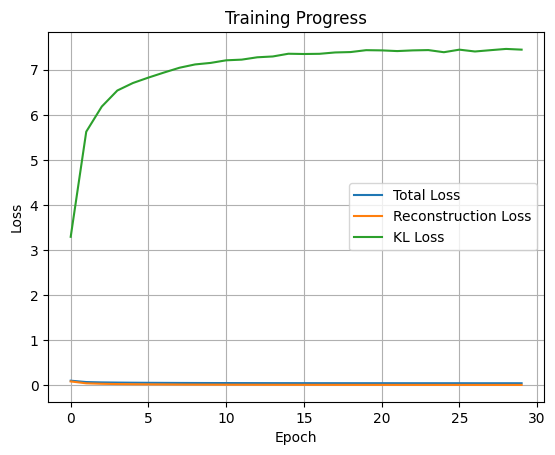

In [108]:
import matplotlib.pyplot as plt

plt.plot(vae._history['loss'], label='Total Loss')
plt.plot(vae._history['reconstruction_loss'], label='Reconstruction Loss')
plt.plot(vae._history['kl_loss'], label='KL Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.grid(True)
plt.show()

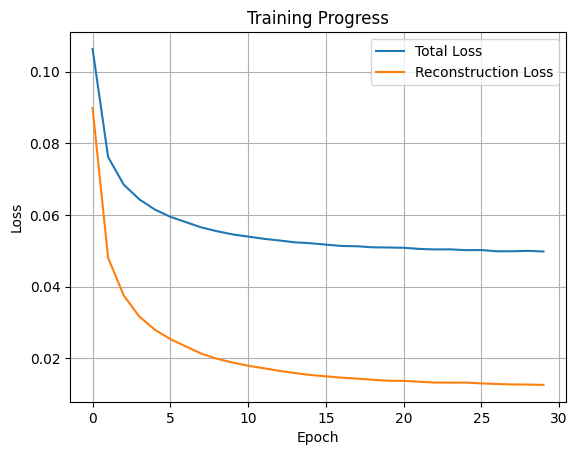

In [109]:
plt.plot(vae._history['loss'], label='Total Loss')
plt.plot(vae._history['reconstruction_loss'], label='Reconstruction Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.grid(True)
plt.show()

In [38]:
batch, label = next(iter(train_dataloader))
batch

tensor([[-1.2156, -0.0354,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,
          0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          1.0000,  0.0000,  0.0000,  1.0000,  0.0000],
        [ 2.3767, -2.4651,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          1.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [-0.1160,  0.7745,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  1.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          1.0000,  0.0000,  0.0000,  1.0000,  0.0000],
        [-1.3623, -1.2503,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  1.0000

Epoch 100, Loss: 0.0082
Epoch 200, Loss: 0.0038
Epoch 300, Loss: 0.0019
Epoch 400, Loss: 0.0010
Epoch 500, Loss: 0.0006
Epoch 600, Loss: 0.0004
Epoch 700, Loss: 0.0003
Epoch 800, Loss: 0.0002
Epoch 900, Loss: 0.0002
Epoch 1000, Loss: 0.0001


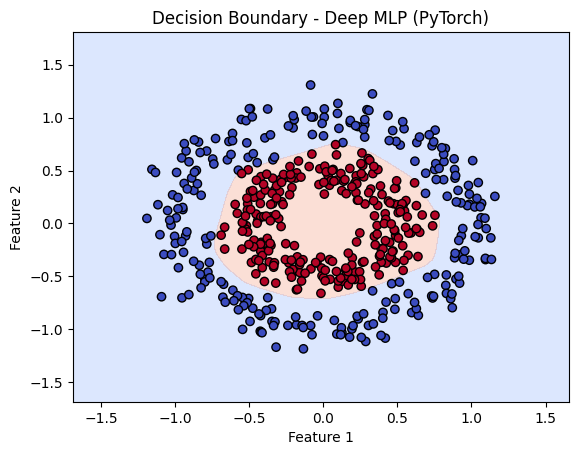

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Generate non-linear data
X, y = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Step 2: Define a deep neural network
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = DeepMLP()

# Step 3: Set up loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Step 4: Training loop
for epoch in range(1000):
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Step 5: Plot decision boundary
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)

    with torch.no_grad():
        Z = model(grid_tensor).reshape(xx.shape).numpy()

    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title("Decision Boundary - Deep MLP (PyTorch)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(model, X, y)
